# Session 5: Introduction to non-linear regression

## Exercise 1: From linear to non-linear

In [1]:
# As usual, we import the libraries we will need during the coding session

import numpy as np
import matplotlib.pyplot as plt

# Recall

In linear regression, the target function $y$ is represented by a **linear** combination of features $x$ such that $y = f(x) + \epsilon$, where $f(x) = \mathbf{w}^T \mathbf{x} = \sum_{i}^d w_i x_i$.

We need to tune the weights $w$ in order to minimise the residuals $\epsilon$ (i.e. the approximation error). For that, we first need to collect some data on the inputs $x$ and the target $y$. 

Then, in the Ordinary Least-Squares approach, the objective is to tune the weights to minimise the euclidean distance between the observations $y$ and the predictions $Xw$:

$w^*= \arg \underset{w}{\min} ||Xw - y||^2_2$

We can use this framework to determine the spring constant of a spring based on noisy data collected in the laboratory (where $x$ is the longitudinal force applied to the spring and $y$ is its length):

K = 1.81
l0 = 10.77
R2 = 0.98


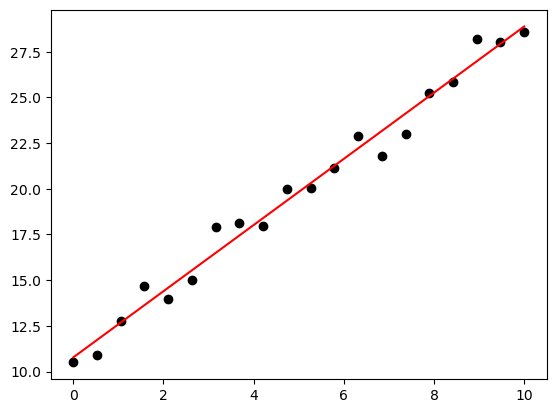

In [2]:
# Fix the seed for reproducibility
np.random.seed(42)

# We collected n=20 measures
n = 20
x = np.linspace(0, 10, n)

# We already know the spring constant and the initial length given in its datasheet
k = 2
l0 = 10

# We made n noisy observations
msrmt_error = 1
y_obs = l0 + k * x + np.random.normal(0, msrmt_error, size=x.shape)

# Plot the data
plt.scatter(x, y_obs, color='k')

# Then, we determine the Hooke's law parameters by performing a linear regression on the data
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y_obs) # Pay attention to the shape of the data
y_pred = model.predict(x.reshape(-1, 1))
plt.plot(x, y_pred, color='r')
print(f'K = {model.coef_[0]:.2f}')
print(f'l0 = {model.intercept_:.2f}')
print(f'R2 = {model.score(x.reshape(-1, 1), y_obs):.2f}')

# The R2 is very high! But what about the estimation of K? 

Now, let's illustrate the limitations: imagine that we are measuring the impulse response of a second-order damped system in automation laboratory. We know that our function must take the following form:

$y = A e^{-\alpha t} \sin(\omega t + \phi)$

where $y$ is the response and $t$ the time. $A$, $\alpha$, $\omega$, $\phi$ are our coefficients to determine. Note that these parameters are generally not part of a linear term.

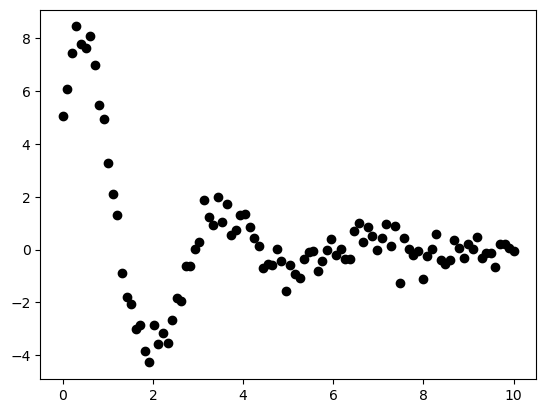

In [13]:
# Fix the seed for reproducibility
np.random.seed(42)

# We collected n=100 measures
n = 100
t = np.linspace(0, 10, n) # 10 seconds experiment

# Let's imagine we know the coefficients
A = 10
alpha = 0.5
omega = 2
phi = 0.5

# We made n noisy observations
msrmt_error = 0.5
y_obs = A * np.sin(omega * t + phi) * np.exp(-alpha * t) + np.random.normal(0, msrmt_error, size=t.shape)

# Plot the data
plt.scatter(t, y_obs, color='k')
plt.show()

How do we find the coefficients? The challenge is that they now appear inside nonlinear terms (sine, exponential...). One might be tempted to apply linear regression anyway, and there is actually a clever trick to partially pull it off in this particular case. We show it here for the sake of completeness, but **this is not what you should do. This session will introduce a much better way to do it**


If one still wants to attempt using linear regression methods:
<br>

Using the angle addition formula $\sin(a+b) = \sin(a)\cos(b)+\cos(a)\sin(b)$, it is possible to expand:

$$y = A e^{-\alpha t} \sin(\omega t + \phi) = e^{-\alpha t}\bigl(\underbrace{A\cos\phi}_{\beta_1}\sin(\omega t) + \underbrace{A\sin\phi}_{\beta_2}\cos(\omega t)\bigr)$$

$$y = \beta_1 \, e^{-\alpha t}\sin(\omega t) + \beta_2 \, e^{-\alpha t}\cos(\omega t)$$

This is now linear in $\beta_1$ and $\beta_2$ — but only if $\alpha$ and $\omega$ are already known. In practice, you would have to guess them by eye from the data, then run the regression.

Eyeballing the plot (again, please do NOT do this, we show this for the sake of completeness): <br>

"I see a period T of roughly 4s between peaks, so $\omega ≈ 2π/T ≈ 1.57$" <br>
"The envelope drops from ~7 to ~2 in 4s, so $\exp(-4α) ≈ 2/7 → α ≈ 0.31$"

Coefficients: [2.90407699 6.63968928]
R2 = 0.80


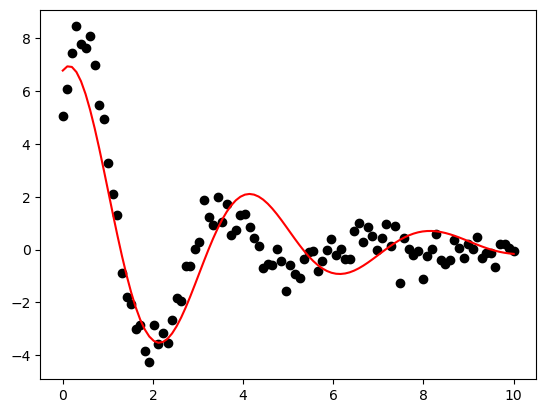

In [16]:
# "I see visually a period T of roughly 4 seconds between each peak... So I estimate omega_est as 2pi/T = 1.57 or so
# " The peak seems to go from 7 to 2 in the first 4 seconds... I can solve exp(-4 alpha) approximately equal to 2/7

alpha_est = 0.31
omega_est = 1.57
X = np.column_stack((np.sin(omega_est*x)*np.exp(-alpha_est*x), np.cos(omega_est*x)*np.exp(-alpha_est*x)))

# Let's copy paste the previous code snippet to see ...
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y_obs) # Pay attention to the shape of the data
y_pred = model.predict(X)

plt.scatter(x, y_obs, color='k')
plt.plot(x, y_pred, color='r')
print(f'Coefficients: {model.coef_}')
print(f'R2 = {model.score(X, y_obs):.2f}')

The fit may look reasonable, and you could probably improve it by tweaking $\alpha$ and $\omega$ by hand. But this approach has serious flaws:

1. You would be either be iterating guesses for key parameters $\alpha$ and $\omega$, either using unnecessary complex computations to find them.
2. It does not generalise. Even on this toy example it is fragile; on a real problem with more parameters or noisier data, it breaks down quickly.
3. It does not scale. The moment your model has more than one or two nonlinear terms, this trick no longer works at all.

Linear regression simply is not the right tool when model parameters appear inside nonlinear terms. This is exactly the problem that nonlinear regression and gradient descent are designed to solve (see below).

Coefficients: [ 8.51021544 -0.73334251  0.40175104]
R2 = 0.56


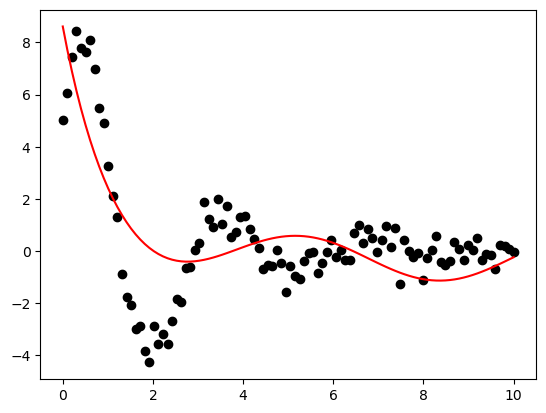

In [ ]:
# DECIDE WHICH VERSION WE KEEP --> not sure that exp + sin + cos   is mathematically relevant given the problem

# Try building a good feature matrix that suits our problem !

#X = np.column_stack((np.exp(-x), np.sin(x), np.cos(x)))

# Let's copy paste the previous code snippet to see ...
#from sklearn.linear_model import LinearRegression
#model = LinearRegression()
#model.fit(X, y_obs) # Pay attention to the shape of the data
#y_pred = model.predict(X)

#plt.scatter(x, y_obs, color='k')
#plt.plot(x, y_pred, color='r')
#print(f'Coefficients: {model.coef_}')
#print(f'R2 = {model.score(X, y_obs):.2f}')

# Did you succeed ?

## Exercise 2: Gradient descent


In linear regression, minimising the least squares loss leads to the normal equations, which are a linear system. For most nonlinear models of practical interest, no general closed-form solution exists, setting the gradient of the loss to zero leads to a system of nonlinear equations. So instead, the idea is to search for the best values iteratively, starting from an initial guess, and progressively reducing the prediction error. This is what gradient descent, a widely used method in optimization, aims to do


### Main idea

Consider a general function $\mathcal{L}(\theta)$ that we want to minimise. If we know its gradient $\nabla_\theta \mathcal{L}$, we know locally which direction makes it increase. As we want to minimize $\mathcal{L}(\theta)$  we step in the opposite direction of that gradient:

$$\theta_{k+1} =  \theta_k - \eta \, \nabla_\theta \mathcal{L}$$


- $\nabla_\theta \mathcal{L}$ points uphill — we go the other way
- $\eta$ is the **learning rate** — the size of each step

Repeat this update iteratively, and $\theta$ will progressively converge toward a minimum of $\mathcal{L}$.


### Implementation

To illustrate the concept, we will now implement gradient descent on the function

$$z(x,y) = 20\sin(x) \cos(y)+x^2+y^2$$

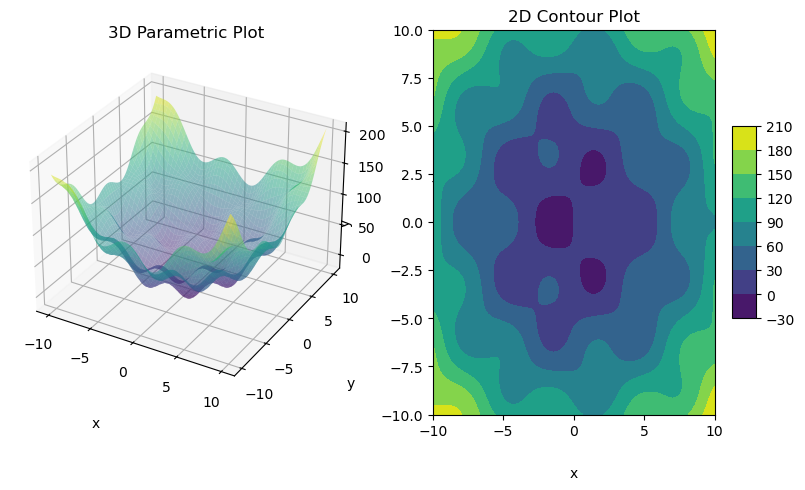

In [17]:
x= np.linspace(-10, 10, 1000)
y= np.linspace(-10, 10, 1000)

X, Y = np.meshgrid(x, y)

Z = 20*(np.sin(X) *np.cos(Y))+X**2+Y**2

# Create Plots
fig= plt.figure(figsize=(10,5))

# Subplot 1: 3D Parametric Plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.grid()
surf = ax.plot_surface(X, Y, Z, cmap=plt.get_cmap('viridis'),alpha= 0.5 )
ax.set_title('3D Parametric Plot')

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('f', labelpad=20)


# Subplot 2: 2D Contour Plot

ax = fig.add_subplot(1, 2, 2)
surf = ax.contourf(X, Y, Z, cmap=plt.get_cmap('viridis') )
ax.set_title('2D Contour Plot')
fig.colorbar(surf, shrink=0.5, aspect=8)

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
plt.show()

### Gradient descent

We will write the gradient descent in form of a function with the following properties:

Input:
- The starting point (coordinates in x and y): `start_indepvar`
- The learning rate : `learning_rate`
- The number of iterations : `num_iterations`

Output:
- The end point (coordinates in x and y): `indepvar`
- The minimum function value after optimization : `z`
- The history of (x, y, z) over the iterations : `history`

Steps:
- Calculate the function value $\boldsymbol{z}_k = f(\boldsymbol{x}_k)$
- Calculate next point as $\boldsymbol{x}_{k+1} = \boldsymbol{x}_k - \delta* \nabla f(\boldsymbol{x}_k)$ (gradient descent step)
- Check convergence :  $|f(\boldsymbol{x}_{k+1} - f(\boldsymbol{x}_k)|< \epsilon$
- Save the solution : `history`

Variables:
- Learning rate: $\delta$
- Threshold to stop the algorithm if convergence is reached: $\epsilon$
- Maximum number of iterations of the gradient descent algorithm: `num_iterations`
- Direction to locally decrease the function value: $\nabla f(\boldsymbol{x}_k)$

As you can observe in the steps above, we have to evaluate the function and compute its gradient at every iteration. Therefore, it is easier if we implement some help functions before to do these two tasks.


╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
#### Help functions: evaluate the function f and compute gradient of this same function

Recall: f(x, y) = sin(x) * cos(y)<br>

function`f(indepvar)`:
- **description**: Evaluates the function f at coordinates (x, y)
- **input**: `indepvar` = array of (2,) $\boldsymbol{x} = [x,y]$
- **output**: `z` = array of (1,)


╌╌╌╌╌╌╌╌╌╌

function`grad_f(indepvar)`:
- **description**: Computes the gradient of function f at coordinates (x, y), which corresponds to computing the partial derivate with respect to x and y $ \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right) $
- **input** : `indepvar` = array of (2,): $\boldsymbol{x} = [x,y]$
- **output**: `grad` = array of (2,): $\nabla f(\boldsymbol{x}_k) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)\Big|_{\boldsymbol{x}_k} $

In [ ]:
# Define the function to be minimized (f(x,y) = sin(x) * cos(y)):
def f(indepvar):
    x = ...; y = ... #retrieve the values x and y from indepvar
    z = ... #use the function and the values x and y
    return z

# Define the partial derivatives of the function (f(x,y) = sin(x) * cos(y)) with respect to x and y
def grad_f(indepvar):
    grad = ... #initialize the grad array
    x = ...; y = ... #gretrieve the values x and y from indepvar
    grad[0] =  ...  # df_dx
    grad[1] =  ... # df_dy
    return grad

#### Gradient descent function
The goal is to write here the following steps of the gradient descent in the function below.

Steps:
- Calculate the function value $\boldsymbol{z}_k = f(\boldsymbol{x}_k)$
- Calculate next point as $\boldsymbol{x}_{k+1} = \boldsymbol{x}_k - \delta* \nabla f(\boldsymbol{x}_k)$ (gradient descent step)
- Check convergence :  $|f(\boldsymbol{x}_{k+1} - f(\boldsymbol{x}_k)|< \epsilon$
- Save the solution : `history`

In [ ]:
# Define the gradient descent algorithm
def gradient_descent(start_indepvar, learning_rate, num_iterations):

    # Initialize values
    indepvar0 = ...
    z0        = ...
    
    #Parameters
    epsilon = 0.001
    history = ... #initialize the history with zeros (size = (num_iterations, 3))
    
    # Perform the gradient descent iterations
    for i in range(num_iterations):
        # Calculate the gradients
        grad = ...
        
        # Update values
        indepvar = ...
        z        = ...
        
        # Save the history of the parameters
        history[i,:]=  ...
        
        # Check convergence 
        if (abs(z-z0)<epsilon ):
            #reshape history and break
            history = history[:i,:]
            break
        else:
            # reinitialize state 0:
            indepvar0 = ...; z0=...
    print(f'Last iteration n= {i+1}; Minimal function value = {z}; abs(z-z0)= {abs(z-z0)}')
    return indepvar, z, history

Execute the gradient descent function and see what happens.

1) What do you observe?

2) Afterwards, re-execute the code with other starting points (for example [5, 4]).<br>
Can you explain what you observe?

In [ ]:
# Perform gradient descent and plot the results
start_xy = [3, 3]
learning_rate = 0.1
num_iterations = 100
indepvar_opt, f_opt, history = ... #Use the gradient descent function that you just defined



# Create Plots
fig= plt.figure(figsize=(10,5))

# Subplot 1: 3D Parametric Plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.grid()
surf = ax.plot_surface(X, Y, Z, cmap=plt.get_cmap('viridis'),alpha= 0.5 )
ax.set_title('3D Parametric Plot')
ax.scatter(*zip(*history), c='k', marker='o', s=5)
ax.scatter(*history[0], c='r', marker='o')
ax.scatter(*history[len(history)-1], c='b', marker='o')

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('f', labelpad=20)


# Subplot 2: 2D Contour Plot

ax = fig.add_subplot(1, 2, 2)
surf = ax.contourf(X, Y, Z, cmap=plt.get_cmap('viridis') )
ax.set_title('2D Contour Plot')
fig.colorbar(surf, shrink=0.5, aspect=8)

nit= history.shape[0]

for it in range(nit-1):
    plt.scatter(history[it,0], history[it,1], c='k', alpha=0.2)

plt.scatter(history[0,0], history[0,1] , c='r') # init
plt.scatter(history[nit-1,0], history[nit-1,1] , c='b') # end


# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
plt.show()

Visualize the evolution of the z-value over the iterations of the gradient descent algorithm

In [ ]:
#create a plot that visualizes the evolution of the error over the iterations

plt.plot(...)
plt.show()

### Gradient descent  estimated:

Not always we know analitically the function of the gradient of the function.<br>
We will estimate the gradient by computing the slope between two points close to each other.

We will create a function called `gradient_descent_estimated` that estimates the gradient.
 - To do:
     - Create the function similarly as before
     - Calculate the difference between the estimated gradient and the exact one at the last iteration

In [ ]:
# Define the gradient descent algorithm with estimation of the gradient
def gradient_descent_estimated(start_indepvar, learning_rate, num_iterations):

    # Initialize values
    indepvar0 = ...
    z0 = ...
    
    #Parameters
    epsilon = 0.001
    history = ...
    
    # Perform the gradient descent iterations
    for i in range(num_iterations):

        # Calculate the estimated gradients by computing the linear slope in the x and y direction in the current point
        dx= 0.01; grad_x = ...
        dy= 0.01; grad_y = ...
        
        grad = ... #combine grad_x and grad_y
        
        # Update values
        indepvar = ...
        z = ...
        
        # Save the history of the parameters
        history[i,:]=  ...
        
        # Check convergence 
        if (abs(z-z0)<epsilon ):
            #reshape history and break
            history = history[:i,:]
            break
        else:
            # reinitialize state 0:
            indepvar0 = ...; z0=...
    
    print(f'Last iteration n= {i+1}; Minimal function value = {z}; abs(z-z0) = {abs(z-z0)}')
    print(f'diff in grad = {grad - grad_f(indepvar)}')
    
    return indepvar, z, history

Apply now the estimated gradient descent algorithm

In [ ]:
# Perform gradient descent and plot the results
start_xy = [3, 3]
learning_rate = 0.1
num_iterations = 1000
indepvar_opt, f_opt, history_est = ... #Use the estimated gradient descent function that you just implemented



# Create Plots
fig= plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.grid()
surf = ax.plot_surface(X, Y, Z, cmap=plt.get_cmap('viridis'),alpha= 0.5 )
ax.set_title('3D Parametric Plot')
ax.scatter(*zip(*history_est), c='k', marker='o', s=5)
ax.scatter(*history_est[0], c='r', marker='o')
ax.scatter(*history_est[len(history_est)-1], c='b', marker='o')

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('f', labelpad=20)

ax = fig.add_subplot(1, 2, 2)
surf = ax.contourf(X, Y, Z, cmap=plt.get_cmap('viridis') )
ax.set_title('2D Contour Plot')
fig.colorbar(surf, shrink=0.5, aspect=8)

nit= history_est.shape[0]

for it in range(nit-1):
    plt.scatter(history_est[it,0], history_est[it,1], c='k', alpha=0.2)

plt.scatter(history_est[0,0], history_est[0,1] , c='r') # init
plt.scatter(history_est[nit-1,0], history_est[nit-1,1] , c='b') # end

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
plt.show()

### Gradient descent using pytorch:   TO CHANGE, STILL FMIN HERE

We will use scipy.optimize library to obtain the minimum of our function

To do: implement the function `scipy.optimize.fmin` to obtain the value of 'indepvar' that minimizes the function f(indepvar)

Check the documentation on how to use this function:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fmin.html

In [ ]:
import scipy.optimize

start_xy = [3, 3]
#retall = True: returns the solutions of all the iterations
[indepvar_opt, indepvar_all] = ...

In [ ]:
# Once you implemented the scipy optimization function, you can run this function to visualize how the solution is converging to the minimum

# Create Plots
fig= plt.figure(figsize=(10,5))

# Subplot 1: 3D Parametric Plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.grid()
surf = ax.plot_surface(X, Y, Z, cmap=plt.get_cmap('viridis'),alpha= 0.5 )
ax.set_title('3D Parametric Plot')

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('f', labelpad=20)


# Subplot 2: 2D Contour Plot
ax = fig.add_subplot(1, 2, 2)
surf = ax.contourf(X, Y, Z, cmap=plt.get_cmap('viridis') )
ax.set_title('2D Contour Plot')
fig.colorbar(surf, shrink=0.5, aspect=8)

nit= len(indepvar_all)

it=0; plt.scatter(indepvar_all[it][0], indepvar_all[it][1] , c='r') #init

for it in np.arange(1,nit): 
    plt.scatter(indepvar_all[it][0], indepvar_all[it][1],  c='black', edgecolors='orange', alpha=1)

plt.scatter(indepvar_all[it][0], indepvar_all[it][1], c='b') #end

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
plt.show()

Zoom in on the region where we are interested in.

What do you observe and how do you explain it? Compare also the optimal values and the number of iterations with the ones obtained with the techniques you implemented above.

Hint: Look also into the documentation of the scipy function

In [ ]:
# Create Plots
fig= plt.figure(figsize=(10,5))

# Subplot 1: 3D Parametric Plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.grid()
surf = ax.plot_surface(X, Y, Z, cmap=plt.get_cmap('viridis'),alpha= 0.5 )
ax.set_title('3D Parametric Plot')

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('f', labelpad=20)


# Subplot 2: 2D Contour Plot
ax = fig.add_subplot(1, 2, 2)
surf = ax.contourf(X, Y, Z, cmap=plt.get_cmap('viridis') )
ax.set_title('2D Contour Plot')
fig.colorbar(surf, shrink=0.5, aspect=8)

nit= len(indepvar_all)

it=0; plt.scatter(indepvar_all[it][0], indepvar_all[it][1] , c='r') #init

for it in np.arange(1,nit): 
    plt.scatter(indepvar_all[it][0], indepvar_all[it][1],  c='black', edgecolors='orange', alpha=1)

plt.scatter(indepvar_all[it][0], indepvar_all[it][1], c='b') #end

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)

# Set the limits of the plot to zoom in on the interesting region
ax.set_xlim([0, 4])
ax.set_ylim([2,4])

plt.show()

| Approach | How it works | When to use |
|---|---|---|
| **Analytical gradient** | Derive $\nabla_\theta \mathcal{L}$ by hand and hard-code it | Rarely done in practice — tedious and error-prone for complex models |
| **Finite differences** | Approximate $\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \Delta\theta) - \mathcal{L}(\theta)}{\Delta\theta}$ | Useful to verify analytical gradients, but too slow for large models |
| **Automatic differentiation** | The library (e.g. PyTorch) tracks operations and computes gradients exactly | The standard in practice — efficient, exact, and works for any model |

## Exercise 3: Back to our nonlinear regression problem

Apply gradient descent method to find optimal coefficients.

In [ ]:
# Fix the seed for reproducibility
np.random.seed(42)

# We collected n=100 measures
n = 100
t = np.linspace(0, 10, n) # 10 seconds experiment

# Let's imagine we know the coefficients
A = 10
alpha = 0.5
omega = 2
phi = 0.5

# We made n noisy observations
msrmt_error = 0.5
y_obs = A * np.sin(omega * t + phi) * np.exp(-alpha * t) + np.random.normal(0, msrmt_error, size=t.shape)

# Plot the data
plt.scatter(t, y_obs, color='k')
plt.show()